# Task 4 — Numerical Prediction (Regression)

**Goal:** predict next-day mean mood as a **continuous value** using two models:
1. **LightGBM** (non-temporal) — gradient boosting on tabular features from 1C
2. **1D CNN** (temporal) — trained on sequential 7-day windows from 1C

**Evaluation:** same per-user temporal split as 2A (75/25). Metrics: MSE, RMSE, MAE.
Per-user statistics recomputed on training data only to prevent leakage.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.impute import SimpleImputer
from scipy.stats import randint, uniform

from src.models import (
    evaluate_regression, temporal_train_test_split, fix_user_features,
    MoodCNNRegressor, train_cnn, predict_cnn,
)
from src.utils import save_figure

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

# Load features
tabular = pd.read_csv('../data/processed/features_tabular.csv')
tabular['date'] = pd.to_datetime(tabular['date'])

seq_data = np.load('../data/processed/features_sequential.npz', allow_pickle=True)
X_seq, y_seq = seq_data['X'], seq_data['y']
channels = seq_data['channels'].tolist()
meta_seq = pd.read_csv('../data/processed/features_sequential_meta.csv')
meta_seq['date'] = pd.to_datetime(meta_seq['date'])

print(f'Tabular: {tabular.shape[0]} instances, {tabular.shape[1]} cols')
print(f'Sequential: X={X_seq.shape}, y={y_seq.shape}, channels={len(channels)}')
print(f'Target range: [{y_seq.min():.1f}, {y_seq.max():.1f}], mean={y_seq.mean():.2f}, std={y_seq.std():.2f}')

Tabular: 1037 instances, 46 cols
Sequential: X=(1037, 7, 12), y=(1037,), channels=12
Target range: [3.0, 9.3], mean=6.99, std=0.75


---
## 1. Train / test split (per-user temporal)

Same split as 2A: first 75% of each user's timeline → train, last 25% → test.
Per-user features recomputed from training data only.


In [2]:
# --- Temporal split ---
train_tab, test_tab = temporal_train_test_split(tabular, train_frac=0.75)
train_tab, test_tab = fix_user_features(train_tab, test_tab)

print(f'Train: {len(train_tab)} instances  |  Test: {len(test_tab)} instances')
print(f'Users in train: {train_tab["id"].nunique()}  |  Users in test: {test_tab["id"].nunique()}')
print(f'Target — train: mean={train_tab["target"].mean():.2f}, std={train_tab["target"].std():.2f}')
print(f'Target — test:  mean={test_tab["target"].mean():.2f}, std={test_tab["target"].std():.2f}')

# --- Align sequential data with the same split ---
train_keys = set(zip(train_tab['id'], train_tab['date']))
test_keys  = set(zip(test_tab['id'], test_tab['date']))

train_seq_mask = np.array([
    (r['id'], pd.Timestamp(r['date'])) in train_keys
    for _, r in meta_seq.iterrows()
])
test_seq_mask = np.array([
    (r['id'], pd.Timestamp(r['date'])) in test_keys
    for _, r in meta_seq.iterrows()
])

X_train_seq, y_train_seq = X_seq[train_seq_mask], y_seq[train_seq_mask]
X_test_seq,  y_test_seq  = X_seq[test_seq_mask],  y_seq[test_seq_mask]

print(f'\nSequential split: train={X_train_seq.shape[0]}, test={X_test_seq.shape[0]}')
assert X_train_seq.shape[0] == len(train_tab), 'Sequential/tabular train mismatch'
assert X_test_seq.shape[0] == len(test_tab), 'Sequential/tabular test mismatch'

Train: 768 instances  |  Test: 269 instances
Users in train: 27  |  Users in test: 27
Target — train: mean=6.98, std=0.75
Target — test:  mean=7.03, std=0.75

Sequential split: train=768, test=269


---
## 2. LightGBM (non-temporal regressor)

### Why LightGBM over Random Forest for regression?
GB's residual-chasing strategy is strongest in regression: early trees capture the dominant linear mood→mood signal, later trees add nonlinear corrections RF can't match. Built-in L1/L2 regularization + early stopping provide explicit overfit control.

### Hyperparameter tuning
RandomizedSearchCV with 50 configurations, 3-fold CV, scoring on negative MSE.

In [3]:
# --- Prepare features ---
feat_cols = [c for c in train_tab.columns if c not in ('id', 'date', 'target')]

imputer = SimpleImputer(strategy='median')
X_train_lgbm = pd.DataFrame(
    imputer.fit_transform(train_tab[feat_cols]),
    columns=feat_cols,
)
X_test_lgbm = pd.DataFrame(
    imputer.transform(test_tab[feat_cols]),
    columns=feat_cols,
)
y_train_lgbm = train_tab['target'].values
y_test_lgbm  = test_tab['target'].values

print(f'Feature matrix: {X_train_lgbm.shape[1]} features')
print(f'NaN after imputation: train={X_train_lgbm.isna().sum().sum()}, test={X_test_lgbm.isna().sum().sum()}')

Feature matrix: 43 features
NaN after imputation: train=0, test=0


In [4]:
# --- Hyperparameter search ---
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [3, 5, 7, 10, -1],
    'num_leaves': randint(15, 63),
    'learning_rate': uniform(0.01, 0.19),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': uniform(0, 1.0),
    'reg_lambda': uniform(0, 1.0),
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbosity=-1, n_jobs=1),
    param_distributions=param_dist,
    n_iter=50,
    cv=KFold(3, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=1,
    random_state=42,
    verbose=0,
)
lgbm_search.fit(X_train_lgbm, y_train_lgbm)

print(f'Best neg_MSE (CV): {lgbm_search.best_score_:.4f}')
print(f'Best RMSE (CV): {np.sqrt(-lgbm_search.best_score_):.4f}')
print(f'Best params: {lgbm_search.best_params_}')

Best neg_MSE (CV): -0.3967
Best RMSE (CV): 0.6298
Best params: {'colsample_bytree': np.float64(0.6424202471887338), 'learning_rate': np.float64(0.01700851999736123), 'max_depth': 3, 'n_estimators': 101, 'num_leaves': 16, 'reg_alpha': np.float64(0.4110370133182313), 'reg_lambda': np.float64(0.033050732900548385), 'subsample': np.float64(0.7380284992106732)}


In [5]:
# --- Evaluate on test set ---
lgbm_model = lgbm_search.best_estimator_
lgbm_pred = lgbm_model.predict(X_test_lgbm)

lgbm_metrics = evaluate_regression(y_test_lgbm, lgbm_pred)
print('=== LightGBM — Test Set ===')
for k, v in lgbm_metrics.items():
    print(f'  {k}: {v:.4f}')

=== LightGBM — Test Set ===
  MSE: 0.3841
  RMSE: 0.6198
  MAE: 0.4492


Saved: figures/4_lgbm_feature_importance.png


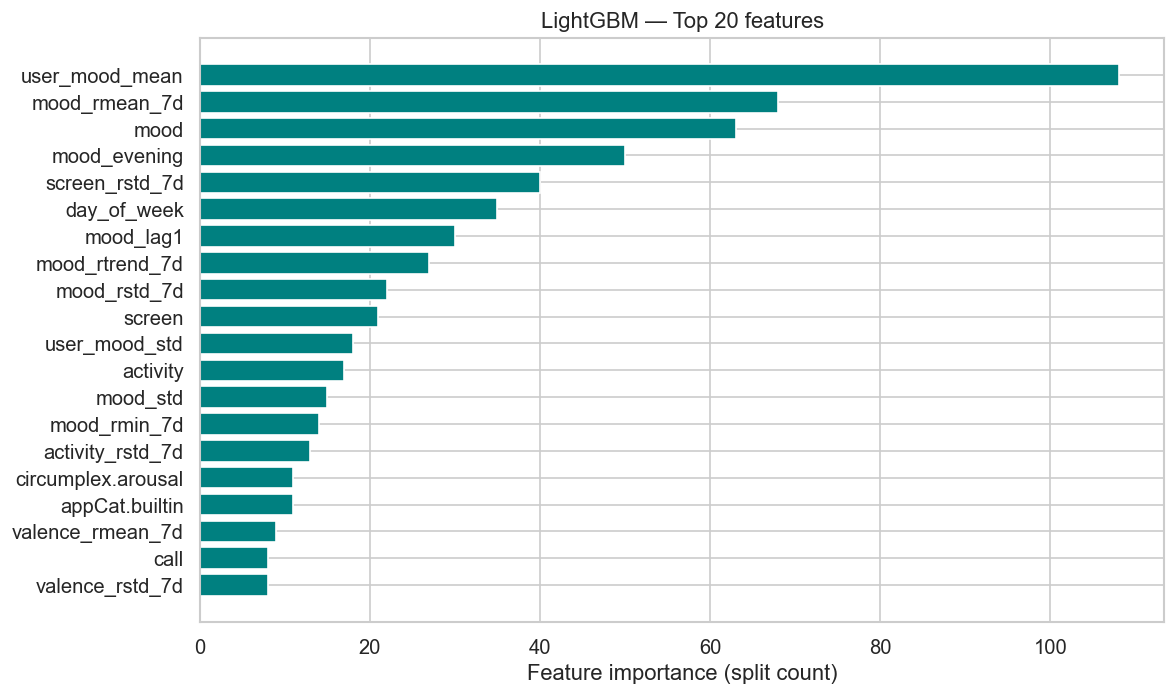

In [6]:
# --- Feature importance ---
importances = lgbm_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 6))
top_names = [feat_cols[i] for i in sorted_idx]
top_vals  = importances[sorted_idx]
ax.barh(range(len(top_names)), top_vals[::-1], color='teal')
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names[::-1])
ax.set_xlabel('Feature importance (split count)')
ax.set_title('LightGBM — Top 20 features')
plt.tight_layout()
save_figure('4_lgbm_feature_importance.png')
plt.show()

---
## 3. 1D CNN (temporal regressor)

Same architecture as the 2A classifier, with two changes:
- Output: linear (no sigmoid) — predicts mood value directly
- Loss: MSE instead of BCE

~7,500 parameters. Trained on 7-day × 12-channel windows.

In [7]:
# --- CNN validation split (temporal, within training set) ---
train_meta = meta_seq[train_seq_mask].reset_index(drop=True)
val_frac = 0.20
cnn_train_idx, cnn_val_idx = [], []
for uid in train_meta['id'].unique():
    u_idx = train_meta[train_meta['id'] == uid].index.tolist()
    cutoff = int(len(u_idx) * (1 - val_frac))
    cnn_train_idx.extend(u_idx[:cutoff])
    cnn_val_idx.extend(u_idx[cutoff:])

X_cnn_train, y_cnn_train = X_train_seq[cnn_train_idx], y_train_seq[cnn_train_idx]
X_cnn_val,   y_cnn_val   = X_train_seq[cnn_val_idx],   y_train_seq[cnn_val_idx]

print(f'CNN train: {len(cnn_train_idx)} | CNN val: {len(cnn_val_idx)} | Test: {X_test_seq.shape[0]}')
print(f'Input shape per instance: {X_cnn_train.shape[1:]} (window × channels)')

CNN train: 605 | CNN val: 163 | Test: 269
Input shape per instance: (7, 12) (window × channels)


In [8]:
# --- Train CNN with a few learning rate options ---
best_cnn = None
best_val_loss = float('inf')
best_lr = None
best_hist = None

for lr in [1e-3, 5e-4, 2e-4]:
    model = MoodCNNRegressor(
        n_channels=X_cnn_train.shape[2],
        seq_len=X_cnn_train.shape[1],
        n_filters_1=32, n_filters_2=64,
        kernel_size=3, dropout=0.3,
    )
    hist = train_cnn(
        model, X_cnn_train, y_cnn_train,
        X_cnn_val, y_cnn_val,
        task='regression', lr=lr, batch_size=32,
        max_epochs=150, patience=15, seed=42,
    )
    best_ep = hist['best_epoch']
    print(f'  lr={lr:.0e}: best_val_loss={min(hist["val_loss"]):.4f} at epoch {best_ep}, '
          f'ran {hist["epochs_run"]} epochs')
    if min(hist['val_loss']) < best_val_loss:
        best_val_loss = min(hist['val_loss'])
        best_cnn = model
        best_lr = lr
        best_hist = hist

print(f'\nSelected lr={best_lr:.0e}')

  lr=1e-03: best_val_loss=0.3857 at epoch 20, ran 35 epochs


  lr=5e-04: best_val_loss=0.4041 at epoch 21, ran 36 epochs


  lr=2e-04: best_val_loss=0.4249 at epoch 25, ran 40 epochs

Selected lr=1e-03


Saved: figures/4_cnn_training_curve.png


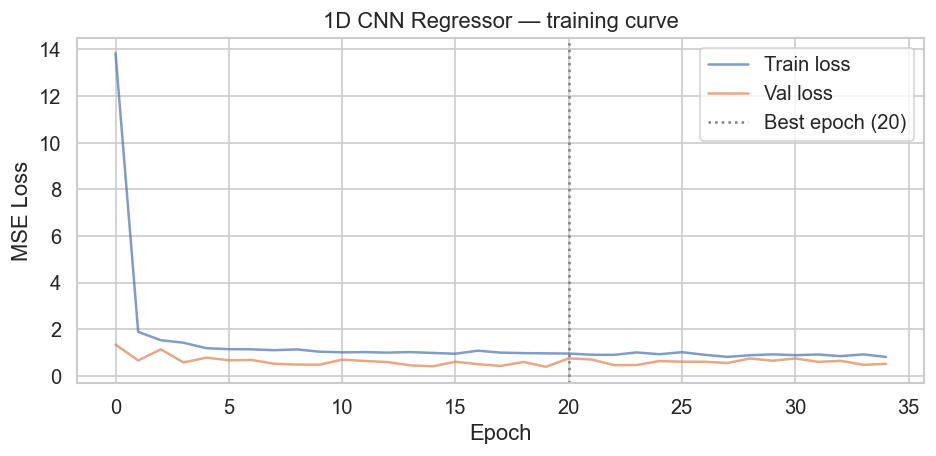

In [9]:
# --- Plot training curve ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_hist['train_loss'], label='Train loss', alpha=0.7)
ax.plot(best_hist['val_loss'], label='Val loss', alpha=0.7)
ax.axvline(best_hist['best_epoch'], color='grey', linestyle=':', label=f'Best epoch ({best_hist["best_epoch"]})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('1D CNN Regressor — training curve')
ax.legend()
plt.tight_layout()
save_figure('4_cnn_training_curve.png')
plt.show()

In [10]:
# --- Evaluate CNN on test set ---
cnn_pred = predict_cnn(best_cnn, X_test_seq, task='regression')

cnn_metrics = evaluate_regression(y_test_seq, cnn_pred)
print('=== 1D CNN Regressor — Test Set ===')
for k, v in cnn_metrics.items():
    print(f'  {k}: {v:.4f}')

=== 1D CNN Regressor — Test Set ===
  MSE: 0.4255
  RMSE: 0.6523
  MAE: 0.4783


---
## 4. Model comparison

In [11]:
# --- Side-by-side metrics ---
comparison = pd.DataFrame({
    'LightGBM': lgbm_metrics,
    '1D CNN': cnn_metrics,
}).T
print('=== Model Comparison ===')
print(comparison.round(4).to_string())

=== Model Comparison ===
             MSE    RMSE     MAE
LightGBM  0.3841  0.6198  0.4492
1D CNN    0.4255  0.6523  0.4783


In [12]:
# --- Save predictions for notebook 5 ---
np.savez(
    '../data/processed/task4_predictions.npz',
    lgbm_pred=lgbm_pred,
    cnn_pred=cnn_pred,
    y_test=y_test_lgbm,
)
print('Saved task4_predictions.npz')

Saved task4_predictions.npz


Saved: figures/4_predicted_vs_actual.png


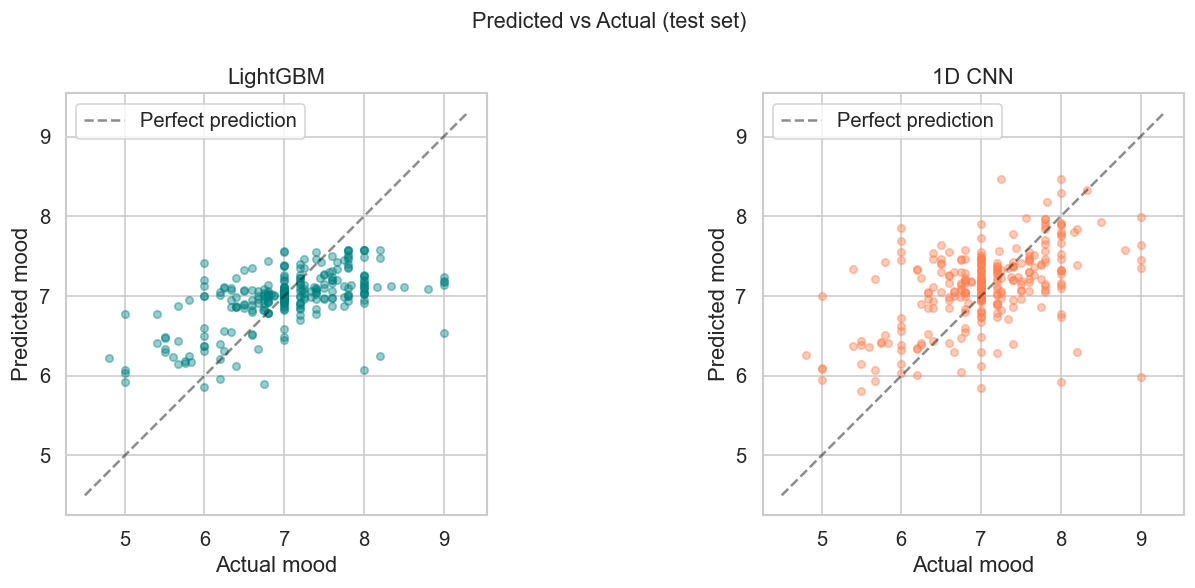

In [13]:
# --- Predicted vs Actual scatter ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, name, color in [
    (axes[0], lgbm_pred, 'LightGBM', 'teal'),
    (axes[1], cnn_pred, '1D CNN', 'coral'),
]:
    ax.scatter(y_test_lgbm, preds, alpha=0.4, s=20, color=color)
    lims = [min(y_test_lgbm.min(), preds.min()) - 0.3,
            max(y_test_lgbm.max(), preds.max()) + 0.3]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
    ax.set_xlabel('Actual mood')
    ax.set_ylabel('Predicted mood')
    ax.set_title(name)
    ax.legend()
    ax.set_aspect('equal')

plt.suptitle('Predicted vs Actual (test set)', fontsize=13)
plt.tight_layout()
save_figure('4_predicted_vs_actual.png')
plt.show()

Saved: figures/4_residuals.png


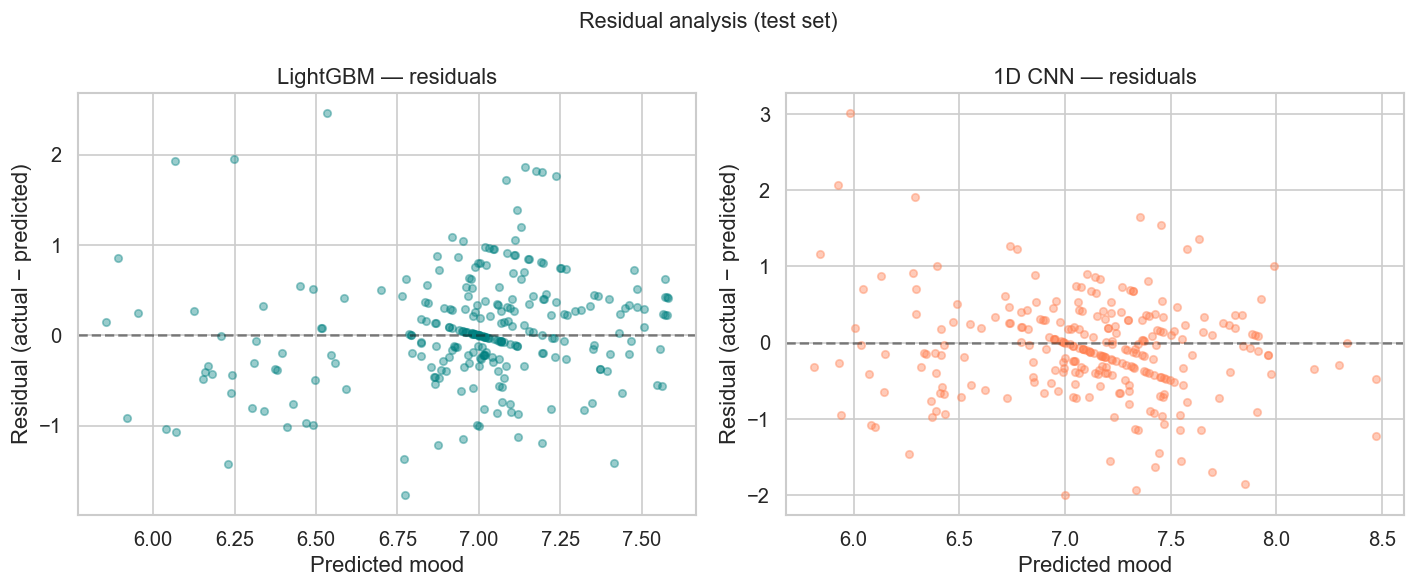

In [14]:
# --- Residual plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, name, color in [
    (axes[0], lgbm_pred, 'LightGBM', 'teal'),
    (axes[1], cnn_pred, '1D CNN', 'coral'),
]:
    residuals = y_test_lgbm - preds
    ax.scatter(preds, residuals, alpha=0.4, s=20, color=color)
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax.set_xlabel('Predicted mood')
    ax.set_ylabel('Residual (actual − predicted)')
    ax.set_title(f'{name} — residuals')

plt.suptitle('Residual analysis (test set)', fontsize=13)
plt.tight_layout()
save_figure('4_residuals.png')
plt.show()

---
## 5. Per-user RMSE breakdown

In [15]:
# --- Per-user RMSE ---
test_with_pred = test_tab[['id']].copy()
test_with_pred['actual'] = y_test_lgbm
test_with_pred['lgbm_pred'] = lgbm_pred
test_with_pred['cnn_pred'] = cnn_pred

per_user = []
for uid, grp in test_with_pred.groupby('id'):
    n = len(grp)
    rmse_lgbm = np.sqrt(np.mean((grp['actual'] - grp['lgbm_pred'])**2))
    rmse_cnn  = np.sqrt(np.mean((grp['actual'] - grp['cnn_pred'])**2))
    per_user.append({'id': uid, 'n_test': n, 'RMSE_LightGBM': rmse_lgbm, 'RMSE_CNN': rmse_cnn})

per_user_df = pd.DataFrame(per_user).sort_values('RMSE_LightGBM')
print(per_user_df.to_string(index=False))
print(f'\nMedian per-user RMSE — LightGBM: {per_user_df["RMSE_LightGBM"].median():.3f}, '
      f'CNN: {per_user_df["RMSE_CNN"].median():.3f}')

     id  n_test  RMSE_LightGBM  RMSE_CNN
AS14.20      10       0.174983  0.333022
AS14.31       9       0.183210  0.368415
AS14.03      11       0.230841  0.259476
AS14.25       6       0.267709  0.311773
AS14.05      12       0.327718  0.404756
AS14.15      13       0.379707  0.425658
AS14.30      10       0.392579  0.164660
AS14.08      11       0.424393  0.645807
AS14.28       8       0.436620  0.593062
AS14.24      13       0.456475  0.527406
AS14.17      10       0.463857  0.490826
AS14.14      10       0.465101  0.632214
AS14.06      10       0.482045  0.485499
AS14.09       9       0.498348  0.580123
AS14.19      10       0.502461  0.517384
AS14.16      11       0.523262  0.534688
AS14.27       9       0.538682  0.633905
AS14.29      10       0.566802  0.762013
AS14.01      10       0.588674  0.328678
AS14.32      10       0.643447  0.846788
AS14.12       9       0.648051  0.655656
AS14.33      10       0.740161  0.755679
AS14.26      11       0.764795  0.919546
AS14.07       9 

Saved: figures/4_per_user_rmse.png


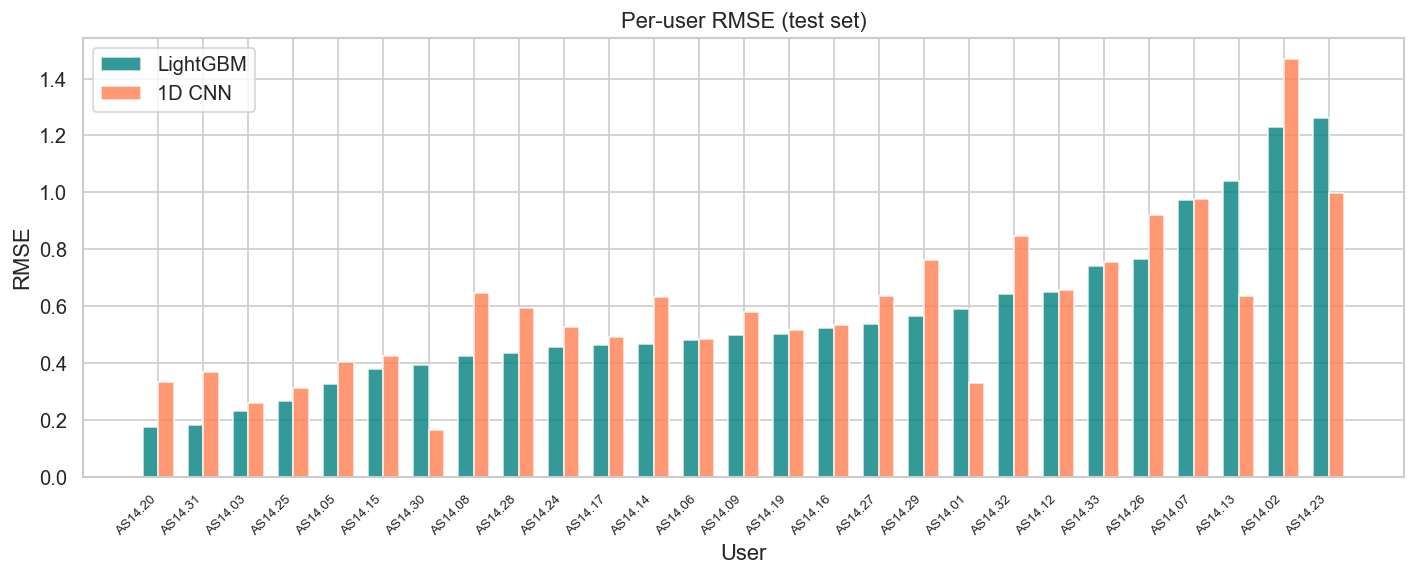

In [16]:
# --- Per-user RMSE bar chart ---
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(per_user_df))
w = 0.35
ax.bar(x - w/2, per_user_df['RMSE_LightGBM'].values, w, label='LightGBM', color='teal', alpha=0.8)
ax.bar(x + w/2, per_user_df['RMSE_CNN'].values, w, label='1D CNN', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(per_user_df['id'].values, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('User')
ax.set_ylabel('RMSE')
ax.set_title('Per-user RMSE (test set)')
ax.legend()
plt.tight_layout()
save_figure('4_per_user_rmse.png')
plt.show()

---
## Summary

| Aspect | LightGBM | 1D CNN |
|---|---|---|
| Input | 43 tabular features (aggregated) | 7 × 12 raw daily channels |
| Temporal awareness | Via lag/rolling features only | Directly from sequence structure |
| Tuning | RandomizedSearchCV (50 configs) | LR grid (3 options) + early stopping |
| Loss function | MSE (via sklearn) | MSE (PyTorch) |

**Classification vs Regression — key differences:**

1. **Information preservation:** regression predicts the exact mood value; classification discards information by thresholding at τ=7.0. A prediction of 6.9 vs 7.1 is a one-class-flip error in classification but only a 0.2 difference in regression.
2. **Class imbalance vanishes:** regression has no classes, so the 38/62 imbalance problem from 2A doesn't exist here. No need for class weights or balanced accuracy.
3. **Same features dominate:** mood history (user_mood_mean, mood_rmean_7d, lag features) remains the strongest signal in both tasks.
4. **Error interpretability:** RMSE is directly interpretable in mood units (e.g., RMSE=0.8 means "off by ~0.8 mood points on average"), unlike accuracy which only counts correct/incorrect.

**Evaluation discipline:** identical to 2A — per-user temporal split, per-user stats from training only, both models evaluated on the same test set.